# **Data preprocessing for ML**

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv(r'/content/drive/MyDrive/colab datasets/train.csv')
df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [ ]:
df=df.drop(columns=['id'],axis=1)

###**Data Preprocessing**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder, MinMaxScaler

In [ ]:
min_max=MinMaxScaler()
min_max

MinMaxScaler()

In [ ]:
cols_for_scaling=['num_lanes','speed_limit','num_reported_accidents']
cols_for_oe=['road_signs_present','public_road','holiday','school_season']
cols_for_ohe=['road_type','lighting','weather','time_of_day']

In [ ]:
order_oe=['False','True']
oe=OrdinalEncoder(categories=order_oe)
ohe=OneHotEncoder()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

ct1 = ColumnTransformer(transformers=[('binary_oe', OrdinalEncoder(), cols_for_oe),
 ('onehot', OneHotEncoder( drop='first',handle_unknown='ignore', sparse_output=False), cols_for_ohe),
                                    ('min_max',MinMaxScaler(),cols_for_scaling)  ], verbose_feature_names_out=False).set_output(transform='pandas')


In [ ]:
ct1

ColumnTransformer(transformers=[('binary_oe', OrdinalEncoder(),
                                 ['road_signs_present', 'public_road',
                                  'holiday', 'school_season']),
                                ('onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['road_type', 'lighting', 'weather',
                                  'time_of_day']),
                                ('min_max', MinMaxScaler(),
                                 ['num_lanes', 'speed_limit',
                                  'num_reported_accidents'])],
                  verbose_feature_names_out=False)

In [ ]:
encoded_cols=ct1.fit_transform(df)
encoded_cols

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.222222,0.142857
1,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.000000,0.222222,0.000000
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,1.000000,0.285714
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.000000,0.777778,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,1.000000,0.285714
517750,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857
517751,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.000000,0.000000
517752,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.428571


In [ ]:
numerical_cols=df[['curvature','accident_risk']]
numerical_cols

,curvature,accident_risk
0,0.06,0.13
1,0.99,0.35
2,0.63,0.30
3,0.07,0.21
4,0.58,0.56
...,...,...
517749,0.10,0.32
517750,0.47,0.26
517751,0.62,0.19
517752,0.63,0.51


In [ ]:
X_final = pd.concat([encoded_cols, numerical_cols], axis=1)


In [ ]:
X_final

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature,accident_risk
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.222222,0.142857,0.06,0.13
1,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.000000,0.222222,0.000000,0.99,0.35
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,1.000000,0.285714,0.63,0.30
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857,0.07,0.21
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.000000,0.777778,0.142857,0.58,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,1.000000,0.285714,0.10,0.32
517750,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857,0.47,0.26
517751,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.62,0.19
517752,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.428571,0.63,0.51


In [ ]:
x=X_final.drop(columns=['accident_risk'],axis=1)

In [ ]:
x

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.222222,0.142857,0.06
1,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.000000,0.222222,0.000000,0.99
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,1.000000,0.285714,0.63
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857,0.07
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.000000,0.777778,0.142857,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,1.000000,0.285714,0.10
517750,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.222222,0.142857,0.47
517751,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.62
517752,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.428571,0.63


In [ ]:
y=X_final['accident_risk']

In [ ]:
y

,accident_risk
0,0.13
1,0.35
2,0.30
3,0.21
4,0.56
...,...
517749,0.32
517750,0.26
517751,0.19
517752,0.51


In [ ]:
X_final.corr()

,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature,accident_risk
road_signs_present,1.000000,0.003828,-0.003813,0.002287,0.000253,0.000705,0.000317,-0.006782,-0.003685,0.006567,-0.004906,0.009339,-0.000498,-0.004461,-0.000162,0.017168,0.000629
public_road,0.003828,1.000000,-0.007920,0.004117,-0.001484,-0.000058,-0.000813,0.000057,-0.000056,0.010340,-0.001142,0.002568,-0.002041,0.011497,-0.007026,0.048220,0.031032
holiday,-0.003813,-0.007920,1.000000,-0.001514,-0.002176,-0.000336,-0.006845,0.016977,-0.002123,0.022232,-0.003769,0.005864,0.002544,0.010992,-0.015053,0.063931,0.051129
school_season,0.002287,0.004117,-0.001514,1.000000,-0.002164,0.001104,0.003317,-0.003191,-0.004432,0.003099,-0.006061,0.012466,-0.001081,0.004392,0.003962,-0.004502,-0.000977
road_type_rural,0.000253,-0.001484,-0.002176,-0.002164,1.000000,-0.497638,0.006600,-0.013023,-0.001509,-0.002719,-0.002599,0.000388,0.000331,0.001285,-0.004631,-0.001515,-0.010121
road_type_urban,0.000705,-0.000058,-0.000336,0.001104,-0.497638,1.000000,-0.008316,0.013205,0.006534,0.008823,0.005322,-0.003358,0.000455,0.008298,0.003660,0.010403,0.021463
lighting_dim,0.000317,-0.000813,-0.006845,0.003317,0.006600,-0.008316,1.000000,-0.487034,0.013395,0.028198,-0.003406,-0.001149,0.001352,0.030502,-0.031970,-0.008077,-0.233032
lighting_night,-0.006782,0.000057,0.016977,-0.003191,-0.013023,0.013205,-0.487034,1.000000,-0.024315,-0.047075,0.003634,0.003786,-0.001150,-0.076318,0.051662,0.000850,0.465798
weather_foggy,-0.003685,-0.000056,-0.002123,-0.004432,-0.001509,0.006534,0.013395,-0.024315,1.000000,-0.484564,0.019279,-0.016999,0.002897,-0.001255,0.001028,0.045515,0.149758
weather_rainy,0.006567,0.010340,0.022232,0.003099,-0.002719,0.008823,0.028198,-0.047075,-0.484564,1.000000,-0.010700,0.013884,-0.006619,-0.078670,0.037935,-0.063868,0.036137


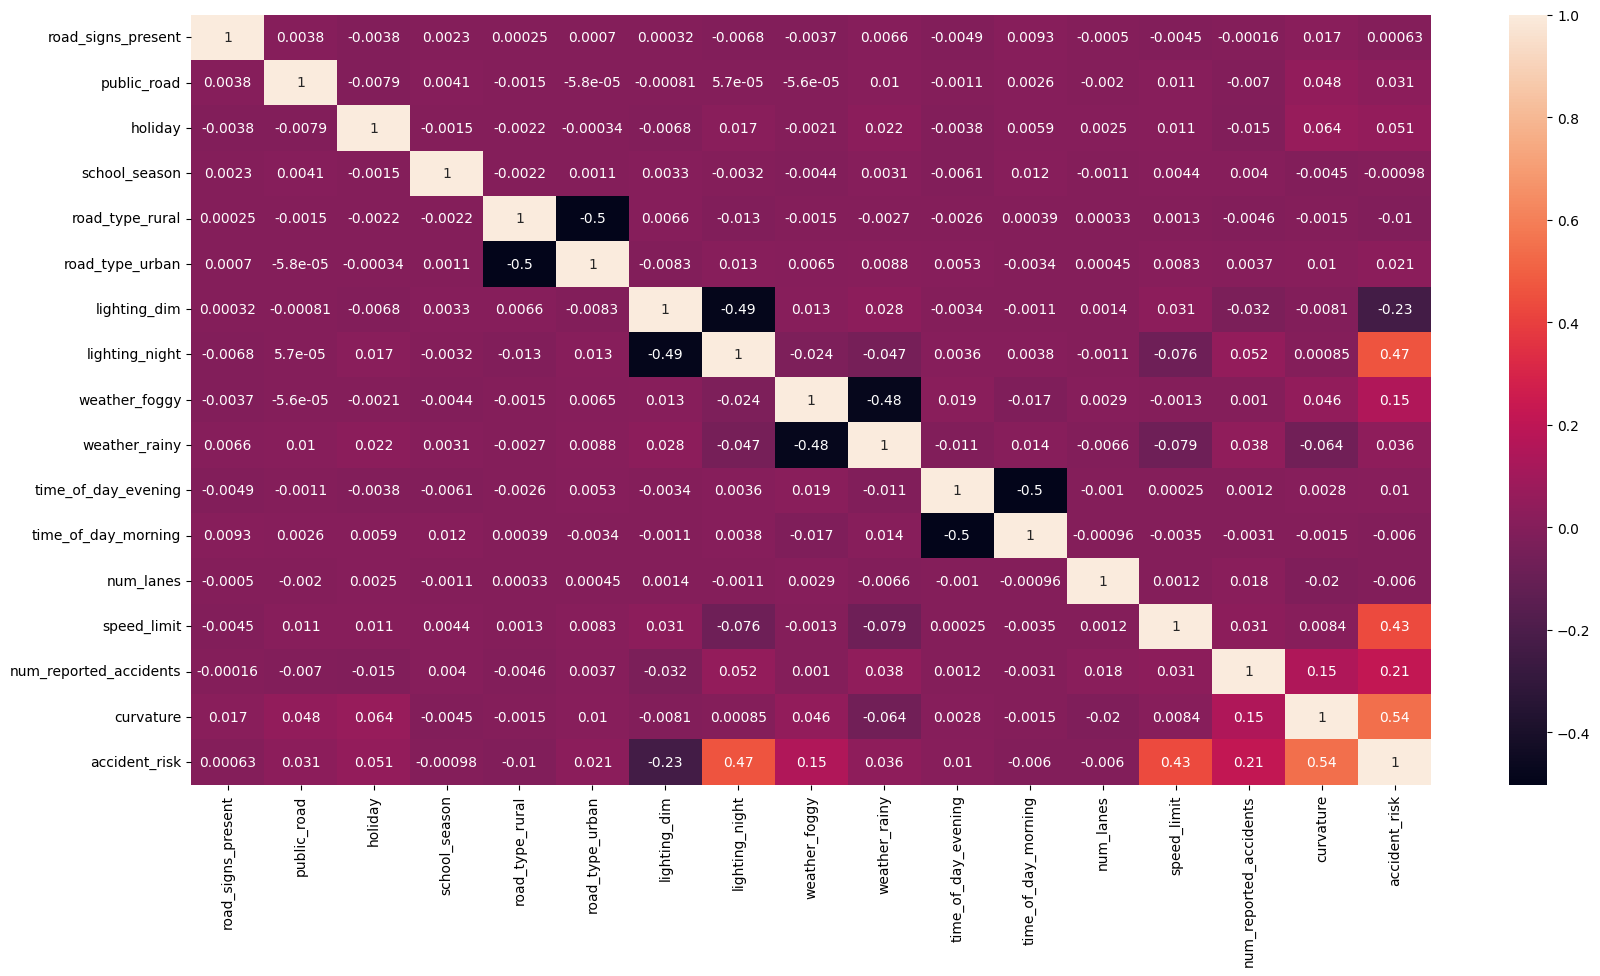

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(X_final.corr(),annot=True);

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((414203, 16), (103551, 16), (414203,), (103551,))

In [ ]:
import statsmodels.api as sm

# **dropping 1**

In [ ]:
x_train_const= sm.add_constant(x_train)
x_train_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
# Instantiate OLS model, Order matters - (y_train, X_train)

ols_obj = sm.OLS(y_train, x_train_const)
ols_obj

In [ ]:
ols = ols_obj.fit()
ols

In [ ]:
# Parameters of model

ols.params

,0
const,-0.048950
road_signs_present,-0.001330
public_road,-0.000697
holiday,-0.000399
school_season,0.000341
road_type_rural,-0.000708
road_type_urban,0.000001
lighting_dim,-0.000171
lighting_night,0.187101
weather_foggy,0.091868


In [ ]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.070e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:09:49   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414186   BIC:                        -9.870e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['features'] = x_train.columns
vif['vif'] = [variance_inflation_factor(x_train.values, var) for var in range(x_train.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif


,features,vif
15,curvature,3.851237
14,num_reported_accidents,2.719369
13,speed_limit,2.551757
12,num_lanes,2.532929
2,holiday,1.953745
1,public_road,1.933746
0,road_signs_present,1.904646
3,school_season,1.896729
6,lighting_dim,1.880277
8,weather_foggy,1.876894


In [ ]:
x_train_1 = x_train.drop(['road_type_urban'], axis = 1)

In [ ]:
x_train_1_const = sm.add_constant(x_train_1)
x_train_1_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols1_obj = sm.OLS(y_train,x_train_1_const)
ols1 = ols1_obj.fit()
ols1

In [ ]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.141e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:10:06   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414187   BIC:                        -9.870e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_1.columns
vif['vif'] = [variance_inflation_factor(x_train_1.values, var) for var in range(x_train_1.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
14,curvature,3.804427
13,num_reported_accidents,2.711315
12,speed_limit,2.525321
11,num_lanes,2.515090
2,holiday,1.949579
1,public_road,1.928659
0,road_signs_present,1.898160
3,school_season,1.890159
5,lighting_dim,1.870555
7,weather_foggy,1.862240


# **dropping 2**

In [ ]:
x_train_2 = x_train_1.drop(['lighting_dim'], axis = 1)

In [ ]:
x_train_2_const = sm.add_constant(x_train_2)
x_train_2_const.head()

,const,road_signs_present,public_road,holiday,school_season,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols2_obj = sm.OLS(y_train,x_train_2_const)
ols2 = ols2_obj.fit()
ols2

In [ ]:
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.223e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:10:20   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414188   BIC:                        -9.870e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_2.columns
vif['vif'] = [variance_inflation_factor(x_train_2.values, var) for var in range(x_train_2.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
13,curvature,3.763055
12,num_reported_accidents,2.702474
11,speed_limit,2.502106
10,num_lanes,2.491057
2,holiday,1.942253
1,public_road,1.921465
0,road_signs_present,1.890600
3,school_season,1.881119
6,weather_foggy,1.846194
9,time_of_day_morning,1.841622


# **dropping 3**

In [ ]:
x_train_3 = x_train_2.drop(['school_season'], axis = 1)

In [ ]:
x_train_3_const = sm.add_constant(x_train_3)
x_train_3_const.head()

,const,road_signs_present,public_road,holiday,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols3_obj = sm.OLS(y_train,x_train_3_const)
ols3 = ols3_obj.fit()
ols3

In [ ]:
print(ols3.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.317e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:10:32   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414189   BIC:                        -9.871e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_3.columns
vif['vif'] = [variance_inflation_factor(x_train_3.values, var) for var in range(x_train_3.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
12,curvature,3.732592
11,num_reported_accidents,2.693059
10,speed_limit,2.480516
9,num_lanes,2.474409
2,holiday,1.937567
1,public_road,1.915294
0,road_signs_present,1.884025
5,weather_foggy,1.836433
7,time_of_day_evening,1.829126
8,time_of_day_morning,1.828576


# **dropping 4**

In [ ]:
x_train_4=x_train_3.drop(['holiday'],axis=1)

In [ ]:
x_train_4_const = sm.add_constant(x_train_4)
x_train_4_const.head()

,const,road_signs_present,public_road,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
143159,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.777778,0.285714,0.43
20172,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.142857,0.18
57926,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.000000,1.000000,0.142857,0.20
193319,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.666667,0.777778,0.142857,0.81
213938,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.666667,0.222222,0.285714,0.43


In [ ]:
ols4_obj = sm.OLS(y_train,x_train_4_const)
ols4 = ols4_obj.fit()
ols4

In [ ]:
print(ols4.summary())

                            OLS Regression Results                            
Dep. Variable:          accident_risk   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                 1.426e+05
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:10:43   Log-Likelihood:             4.9362e+05
No. Observations:              414203   AIC:                        -9.872e+05
Df Residuals:                  414190   BIC:                        -9.871e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [ ]:
vif = pd.DataFrame()
vif['features'] = x_train_4.columns
vif['vif'] = [variance_inflation_factor(x_train_4.values, var) for var in range(x_train_4.shape[1])]
vif = vif.sort_values(by = 'vif', ascending = False)
vif

,features,vif
11,curvature,3.630846
10,num_reported_accidents,2.691741
8,num_lanes,2.458301
9,speed_limit,2.455779
1,public_road,1.912880
0,road_signs_present,1.879833
4,weather_foggy,1.824562
6,time_of_day_evening,1.821061
7,time_of_day_morning,1.819240
5,weather_rainy,1.690757


In [ ]:
x_train_4.columns

Index(['road_signs_present', 'public_road', 'road_type_rural',
       'lighting_night', 'weather_foggy', 'weather_rainy',
       'time_of_day_evening', 'time_of_day_morning', 'num_lanes',
       'speed_limit', 'num_reported_accidents', 'curvature'],
      dtype='object')

In [ ]:
x_test_new=x_test[x_train_4.columns]
x_test_new

,road_signs_present,public_road,road_type_rural,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,num_lanes,speed_limit,num_reported_accidents,curvature
50309,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.444444,0.285714,0.09
95219,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.000000,0.777778,0.000000,0.14
197653,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.333333,0.000000,0.000000,0.51
111236,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.777778,0.142857,0.33
147247,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.777778,0.142857,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...
453214,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.333333,0.000000,0.000000,0.19
190565,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.666667,0.444444,0.000000,0.63
357332,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.333333,0.444444,0.142857,0.68
503653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.000000,0.285714,0.43


# **Model Building**

##**DecisionTreeRegressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
dt=DecisionTreeRegressor()
dt

DecisionTreeRegressor()

In [ ]:
dt.fit(x_train_4,y_train)

DecisionTreeRegressor()

In [ ]:
dt.score(x_train_4,y_train)

0.972414346549076

In [ ]:
y_pred=dt.predict(x_test_new)
y_pred

array([0.13333333, 0.36      , 0.26      , ..., 0.4       , 0.21      ,
       0.14      ])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.774632659231177

0.006222886794189709

0.06067508342258467

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = DecisionTreeRegressor(random_state=42)

param_dist = {
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 30),
    "criterion": ["squared_error"],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,                       # number of random trials
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_4, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197d08c0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197f1520>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78532d9905f0>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
search.best_params_

{'criterion': 'squared_error',
 'max_depth': 9,
 'min_samples_leaf': 20,
 'min_samples_split': 30}

In [ ]:
search.best_score_


np.float64(-0.003201833805001931)

In [ ]:
search.best_estimator_


DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30,
                      random_state=42)

In [ ]:
search.best_estimator_


DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30,
                      random_state=42)

In [ ]:
dt=DecisionTreeRegressor(**search.best_params_)
dt

DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30)

In [ ]:
dt.fit(x_train_4,y_train)

DecisionTreeRegressor(max_depth=9, min_samples_leaf=20, min_samples_split=30)

In [ ]:
dt.score(x_train_4,y_train)

0.8857326384291131

In [ ]:
y_pred=dt.predict(x_test_new)
y_pred

array([0.13205272, 0.33145038, 0.25069249, ..., 0.40795794, 0.14019116,
       0.15706609])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8835703822290052

0.0032148772240379064

0.043960347246932735

## **RandomForestRegressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=30)
rf

RandomForestRegressor(n_estimators=30)

In [ ]:
rf.fit(x_train_4,y_train)

RandomForestRegressor(n_estimators=30)

In [ ]:
rf.score(x_train_4,y_train)

0.9600738803551666

In [ ]:
y_pred=rf.predict(x_test_new)
y_pred

array([0.13630556, 0.34577778, 0.26822222, ..., 0.41761111, 0.17666667,
       0.14391667])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8527795744109813

0.0040650789910710505

0.04939468976034269

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(n_splits=3, shuffle=True, random_state=42)

model = RandomForestRegressor(random_state=42)

param_forest = {
    "n_estimators": randint(2,20),
    'criterion':['squared_error'],
    'max_depth': randint(2,30),
    'min_samples_split' : randint(2,30),
    'min_samples_leaf': randint(2,30),
    }
search=RandomizedSearchCV(estimator=model,
                          param_distributions=param_forest,
                          n_iter=10,
                          scoring="neg_mean_squared_error",
                          cv=cv,
                          n_jobs=-1,
                          random_state=42,
                          verbose=1)
search.fit(x_train_4,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
                   param_distributions={'criterion': ['squared_error'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197d1520>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197f2f30>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197c5e50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7853197c71a0>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
search.best_params_

{'criterion': 'squared_error',
 'max_depth': 9,
 'min_samples_leaf': 22,
 'min_samples_split': 8,
 'n_estimators': 12}

In [ ]:
search.best_estimator_

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12, random_state=42)

In [ ]:
search.best_score_

np.float64(-0.003192775562425076)

In [ ]:
rf=RandomForestRegressor(**search.best_params_)
rf

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12)

In [ ]:
rf.fit(x_train_4,y_train)

RandomForestRegressor(max_depth=9, min_samples_leaf=22, min_samples_split=8,
                      n_estimators=12)

In [ ]:
rf.score(x_train_4,y_train)

0.8860813062446679

In [ ]:
y_pred=rf.predict(x_test_new)
y_pred

array([0.12907019, 0.33306887, 0.25151179, ..., 0.41074004, 0.14008612,
       0.15683271])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8839032344776259

0.0032056864430876054

0.04388815656996512

##**LinearRegressor**

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import loguniform

cv = KFold(n_splits=3, shuffle=True, random_state=42)

model_type = "ElasticNet"  # "Ridge", "Lasso", or "ElasticNet"

if model_type == "Ridge":
    model = Ridge()
    param_dist = {
        "alpha": loguniform(1e-4, 1e2)
    }

elif model_type == "Lasso":
    model = Lasso(max_iter=10000)
    param_dist = {
        "alpha": loguniform(1e-4, 1e2)
    }

elif model_type == "ElasticNet":
    model = ElasticNet(max_iter=10000)
    param_dist = {
        "alpha": loguniform(1e-4, 1e2),
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="neg_mean_squared_error",
    random_state=42
)

search.fit(x_train_4, y_train)

RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=ElasticNet(max_iter=10000), n_iter=20,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78532519a330>,
                                        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
search.best_params_

{'alpha': np.float64(0.00013289448722869195), 'l1_ratio': 0.3}

In [ ]:
search.best_estimator_


ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3,
           max_iter=10000)

In [ ]:
en=ElasticNet(**search.best_params_)
en

ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3)

In [ ]:
en.fit(x_train_4,y_train)

ElasticNet(alpha=np.float64(0.00013289448722869195), l1_ratio=0.3)

In [ ]:
en.score(x_train_4,y_train)

0.8051436563728287

In [ ]:
y_pred=en.predict(x_test_new)
y_pred

array([0.20641034, 0.26835894, 0.20965018, ..., 0.4757864 , 0.12355873,
       0.22769922])

In [ ]:
r2_score(y_test,y_pred)
mean_squared_error(y_test,y_pred)
mean_absolute_error(y_test,y_pred)

0.8041856608970817

0.00540686357109071

0.058306879420443394

##**Saving the Best Model for Deployment**

#### **I want to use RandomForest Model for Deployment because it's Training and Testing Scores are comparatively high as compared to other models**

In [ ]:
import pickle

# 1. Create model
rf = rf.fit(x_train_4,y_train)


# 2. Save the FITTED model
with open("rf.pkl", "wb") as file:
    pickle.dump(rf, file)


from google.colab import files
files.download("rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>